# **Assignment03: Deep Learning**
- `Name  : Rana Taqveem Ul Hassan`
- `Roll #: 25280030`

# **Task 1: Custom CNNs and Shortcut Learning**

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sns
import random

# Set seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# DEVICE = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using Device: {DEVICE}")

Using Device: cpu


In [2]:
isLocal = False
isColab = True
DATASET_PATH = '/content/drive/MyDrive/MSAI/AI-600/assignment_03/dataset'

In [12]:
import os
import zipfile

root_path = '/content/drive/MyDrive/MSAI/AI-600/assignment_03/dataset/'
if isLocal:
    DATASET_PATH = './'
elif isColab:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    os.chdir(root_path)

    ZIP_PATH = os.path.join(root_path, 'cmnist.zip')
    extract_to = '/content/dataset'

    if not os.path.isfile(extract_to):
      os.makedirs(extract_to, exist_ok=True)
      with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        print('Extracting:', z.namelist())
        z.extractall(extract_to)
        print("Done!")

    DATASET_PATH = extract_to


Mounted at /content/drive
Extracting: ['test_biased.pt', '__MACOSX/._test_biased.pt', 'test_unbiased.pt', '__MACOSX/._test_unbiased.pt', 'train_biased.pt', '__MACOSX/._train_biased.pt']
Done!


**Part A: Standard MNIST**
Architecture Design: Implement a custom CNN in PyTorch to classify the standard
MNIST dataset. Your model must adhere to the following constraints:
• Maximum of 3 Convolutional Layers.
• Maximum of 2 Fully Connected (Linear) Layers.
• Total trainable parameters must not exceed 50,000. (Hint: Use pooling and control
your channel dimensions to stay under the limit)

In [13]:
mnist_transformer = transforms.Compose([

    transforms.ToTensor(),
    transforms.Normalize((0.1307,),(0.3081))
])

train_mnist_ds = datasets.MNIST(root='./data', transform=mnist_transformer, download=True, train=True)
test_mnist_ds = datasets.MNIST(root='./data', transform=mnist_transformer, download=True, train=False)

total_train_mnist_len = len(train_mnist_ds)
train_mnist_size = int(total_train_mnist_len * 0.8)
val_mnist_size = total_train_mnist_len - train_mnist_size
train_mnist_subset, val_mnist_subset = torch.utils.data.random_split(train_mnist_ds, [train_mnist_size, val_mnist_size])

all_mnist_labels = train_mnist_ds.targets
classes_mnist = all_mnist_labels.unique()
print(all_mnist_labels)         # Output: tensor([5, 0, 4, ..., 5, 6, 8])
print(all_mnist_labels.unique()) # Output: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

BATCH_SIZE = 64
train_mnist_loader = DataLoader(train_mnist_subset, batch_size=BATCH_SIZE, shuffle=True)
val_mnist_loader = DataLoader(val_mnist_subset, batch_size=BATCH_SIZE, shuffle=False)
test_mnist_loader = DataLoader(test_mnist_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Train Samples: {len(train_mnist_ds)}")
print(f"Train Samples: {len(train_mnist_subset)}")
print(f"Validation Samples: {len(val_mnist_subset)}")

print(f"DateLoader batch size: {BATCH_SIZE}")
print(f"Trainning batches: {len(train_mnist_loader)}")
print(f"Validation batches: {len(val_mnist_loader)}")
print(f"Test batches: {len(test_mnist_loader)}")

# Print split sizes

tensor([5, 0, 4,  ..., 5, 6, 8])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Total Train Samples: 60000
Train Samples: 48000
Validation Samples: 12000
DateLoader batch size: 64
Trainning batches: 750
Validation batches: 188
Test batches: 157


torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])
torch.Size([64, 1, 28, 28])


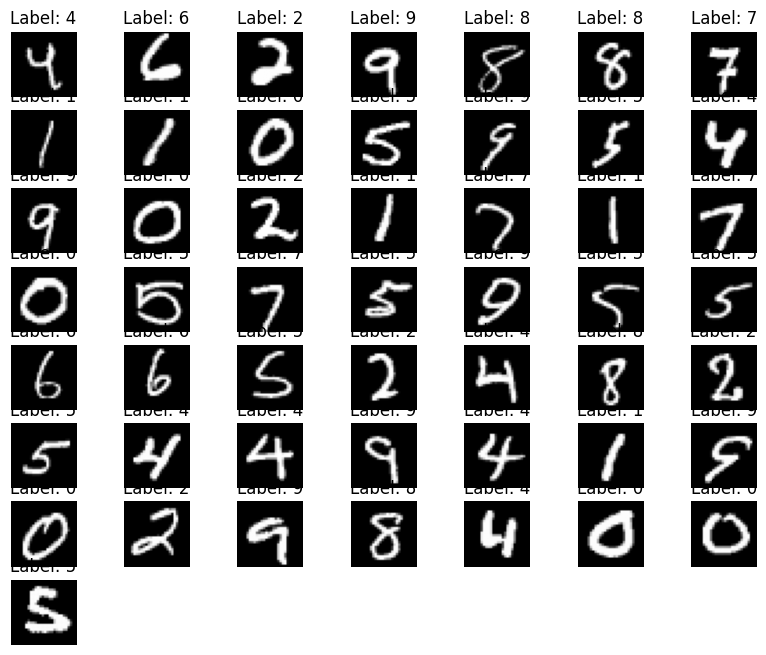

In [14]:
found_images = {}
for image, label in train_mnist_loader:
  print(image.shape)
  if label not in found_images:
    found_images[label] = image

  if len(found_images) == 10:
    break

fig = plt.figure(figsize=(10, 10))
for i, (label, images) in enumerate(found_images.items()):

  for j in range(5):

    ax = fig.add_subplot(10, 7, i * 5 + j + 1)
    ax.imshow(images[j].squeeze(), cmap='gray')
    ax.set_title(f"Label: {label[j]}")
    ax.axis('off')


In [15]:
def layer_info(layer, input_shape):
    """
    Args:
        layer: nn.Conv2d or nn.MaxPool2d object
        input_shape: (C, H, W) tuple
    Returns:
        prints params and output shape
    """
    C_in, H_in, W_in = input_shape

    if isinstance(layer, nn.Conv2d):
        k  = layer.kernel_size[0]
        s  = layer.stride[0]
        p  = layer.padding[0]
        C_out = layer.out_channels

        params = (k * k * C_in + 1) * C_out
        H_out  = (H_in + 2*p - k) // s + 1
        W_out  = (W_in + 2*p - k) // s + 1

        print(f"Conv2d   | params: ({k}×{k}×{C_in} + 1) × {C_out} = {params:,}")
        print(f"         | output: [{C_out}, {H_out}, {W_out}]")
        return (C_out, H_out, W_out)

    elif isinstance(layer, nn.MaxPool2d):
        k = layer.kernel_size if isinstance(layer.kernel_size, int) else layer.kernel_size[0]
        s = layer.stride      if isinstance(layer.stride, int)      else layer.stride[0]

        H_out = (H_in - k) // s + 1
        W_out = (W_in - k) // s + 1

        print(f"MaxPool2d| params: 0")
        print(f"         | output: [{C_in}, {H_out}, {W_out}]")
        return (C_in, H_out, W_out)

    else:
        print(f"Unsupported layer type: {type(layer)}")
        return input_shape

def conv_info(C_in, H_in, W_in, C_out, k, s=1, p=0):
    params = (k * k * C_in + 1) * C_out
    H_out  = (H_in + 2*p - k) // s + 1
    W_out  = (W_in + 2*p - k) // s + 1
    print(f"Conv2d   | params: ({k}×{k}×{C_in} + 1) × {C_out} = {params:,} | output: [{C_out}, {H_out}, {W_out}]")
    return (C_out, H_out, W_out)

def pool_info(C_in, H_in, W_in, k, s):
    H_out = (H_in - k) // s + 1
    W_out = (W_in - k) // s + 1
    print(f"MaxPool2d| params: 0                                              | output: [{C_in}, {H_out}, {W_out}]")
    return (C_in, H_out, W_out)

def linear_info(in_f, out_f):
    params = in_f * out_f + out_f
    print(f"Linear   | params: {in_f}×{out_f} + {out_f} = {params:,}         | output: [{out_f}]")
    return out_f

In [18]:

TRAIN_LOSS = 'train_loss'
TRAIN_ACC = 'train_acc'
VAL_LOSS = 'val_loss'
VAL_ACC = 'val_acc'

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0
    for images, labels in loader:
      optimizer.zero_grad()
      images = images.to(DEVICE)
      outputs = model(images)

      labels = labels.to(DEVICE)
      loss = criterion(outputs, labels)

      _, predicted_classes = torch.max(outputs.data, 1)
      accurate_predictions += (predicted_classes == labels).sum().item()

      total_loss += loss.item() * images.size(0)
      sample_count += images.size(0)
      loss.backward()
      optimizer.step()

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def evaluate(model, loader, criterion):

    model.eval()

    total_loss = 0.0
    accurate_predictions = 0
    sample_count = 0

    with torch.no_grad():
      for images, labels in loader:
        images = images.to(DEVICE)
        outputs = model(images)

        labels = labels.to(DEVICE)
        loss = criterion(outputs, labels)
        _, predicted_classes = torch.max(outputs.data, 1)
        accurate_predictions += (predicted_classes == labels).sum().item()

        total_loss += loss.item() * images.size(0)
        sample_count += images.size(0)

    avg_loss = total_loss / sample_count
    accuracy =  100 * accurate_predictions / sample_count

    return avg_loss, accuracy

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs=7):
  results = {
      TRAIN_LOSS: [],
      TRAIN_ACC: [],
      VAL_LOSS: [],
      VAL_ACC : []
  }

  for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    results[TRAIN_LOSS].append(train_loss)
    results[TRAIN_ACC].append(train_acc)

    val_loss, val_acc = evaluate(model, val_loader, criterion=criterion)
    results[VAL_LOSS].append(val_loss)
    results[VAL_ACC].append(val_acc)

    print(f"Epoch: {epoch+1}/{num_epochs} | "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% | "
          f"Val Loss {val_loss:.2f}% Val Acc:{val_acc:.2f}%")

  return results

def test_and_report(model, test_loader, criterion, classes):

  test_loss, test_acc = evaluate(model, test_loader, criterion)

  y_true = []
  y_pred = []
  y_images = []

  model.eval()
  with torch.no_grad():
    for images, labels in test_loader:
      images = images.to(DEVICE)
      labels = labels.to(DEVICE)

      outputs = model(images)
      _, predictions = torch.max(outputs.data, 1)

      y_true.extend(labels.cpu().tolist())
      y_pred.extend(predictions.cpu().tolist())
      # y_images.extend(images.cpu())

  print("-" * 30)
  print(f"FINAL TEST RESULT")
  print(f"Test Loss: {test_loss:.4f}")
  print(f"Test Accuracy: {test_acc:.2f}%")
  print("-" * 30)

  classes_list = [str(c.item() if torch.is_tensor(c) else c) for c in classes]

  cr = classification_report(y_true, y_pred, target_names=classes_list)
  print("\nClassification Report:\n", cr)

  return test_loss, test_acc, y_true, y_pred

def plot_loss_acc(results):
  print("-" * 30)
  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_LOSS], label='Training Loss')
  plt.plot(results[VAL_LOSS], label='Validation Loss')
  plt.legend()

  print("-" * 30)
  plt.figure(figsize=(6,4))
  plt.plot(results[TRAIN_ACC], label='Training Accuracy')
  plt.plot(results[VAL_ACC], label='Validation Accuracy')
  plt.legend()

  print("-" * 30)


In [9]:
class SimpleCNN(nn.Module):
    def __init__(self, input_channels):
      super(SimpleCNN, self).__init__()

      self.input_channels = input_channels
      self.conv1 = nn.Conv2d(in_channels=self.input_channels, out_channels=32, kernel_size=3, stride=2, padding=1)
      self.pool1 = nn.MaxPool2d(kernel_size=2, stride=1)

      self.conv2 = nn.Conv2d(in_channels=32, out_channels=32, kernel_size=3, stride=1)
      self.pool2 = nn.MaxPool2d(kernel_size=2, stride=1)

      self.conv3 = nn.Conv2d(in_channels=32, out_channels=16, kernel_size=3, stride=1)
      self.pool3 = nn.MaxPool2d(kernel_size=1, stride=1)

      self.l1 = nn.Linear(16*8*8, 32)
      self.l2 = nn.Linear(32, 16)
      self.l3 = nn.Linear(16, 10)

    def forward(self, x):
      x = self.pool1(F.relu(self.conv1(x)))
      x = self.pool2(F.relu(self.conv2(x)))
      x = self.pool3(F.relu(self.conv3(x)))

      x = x.flatten(start_dim=1)
      x = F.relu(self.l1(x))
      x = F.relu(self.l2(x))

      return self.l3(x)


def count_parameters(model):
  return sum(p.numel() for p in model.parameters() if p.requires_grad)

grayscaleCNN = SimpleCNN(input_channels=1).to(DEVICE)
print(f"grayscaleCNN Parameters: {count_parameters(grayscaleCNN)}")


grayscaleCNN Parameters: 47690


------------------------------
                              
Epoch: 1/7 | Train Loss: 0.3667, Train Acc: 88.12% | Val Loss 0.13% Val Acc:96.01%
Epoch: 2/7 | Train Loss: 0.0947, Train Acc: 97.10% | Val Loss 0.07% Val Acc:97.75%
Epoch: 3/7 | Train Loss: 0.0659, Train Acc: 97.99% | Val Loss 0.07% Val Acc:97.89%
Epoch: 4/7 | Train Loss: 0.0551, Train Acc: 98.24% | Val Loss 0.07% Val Acc:98.03%
Epoch: 5/7 | Train Loss: 0.0452, Train Acc: 98.59% | Val Loss 0.05% Val Acc:98.62%
Epoch: 6/7 | Train Loss: 0.0406, Train Acc: 98.70% | Val Loss 0.05% Val Acc:98.44%
Epoch: 7/7 | Train Loss: 0.0361, Train Acc: 98.85% | Val Loss 0.05% Val Acc:98.53%
------------------------------
                              
------------------------------
FINAL TEST RESULT
Test Loss: 0.0390
Test Accuracy: 98.65%
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       980
           1       0.99      0.99      0.

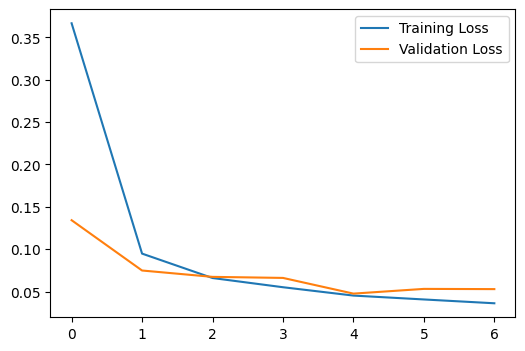

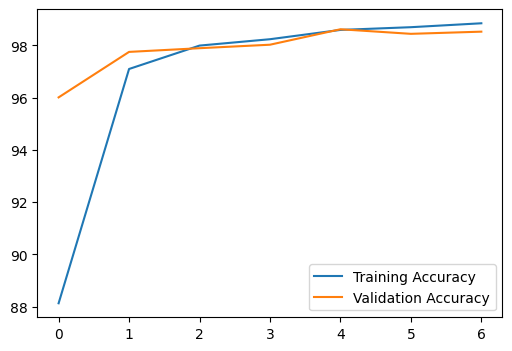

In [10]:

criterion_cel = nn.CrossEntropyLoss()
optimizer_adam = optim.Adam(grayscaleCNN.parameters(), lr=0.001)
print("-" * 30)
print(" " * 30)
results = train_model(grayscaleCNN,
                      train_mnist_loader,
                      val_mnist_loader,
                      criterion_cel,
                      optimizer_adam,
                      num_epochs=7)

print("-" * 30)
print(" " * 30)

test_and_report(grayscaleCNN, test_mnist_loader, criterion_cel, classes_mnist)

print("-" * 30)
print(" " * 30)
plot_loss_acc(results)

**Analytical Question 1.1: Examine your loss curves. Did your model overfit, underfit,
or generalize well? Justify your answer by referencing the gap (or lack thereof) between
the training and validation curves.**

My model shows strong generalization on the grayscale MNIST dataset with a **high test accuracy of 98.65%**.

when we look at the training vs validation loss/accuracy curves we see that, initially the validation accuracy started strongly, roughly 8% higher than the training accuracy. By **epoch 5**, the **training accuracy (98.59%)** and the **validation accuracy (98.62%)** interset showing that the model is not underfitting.

To avoid overfitting, the training was stopped at the **epcoh 7**, and the final gap between the training and the validation accuracy stayed under 0.4% which strongly shows that model is generalized quite well, which is proven by its performance on unseen data.

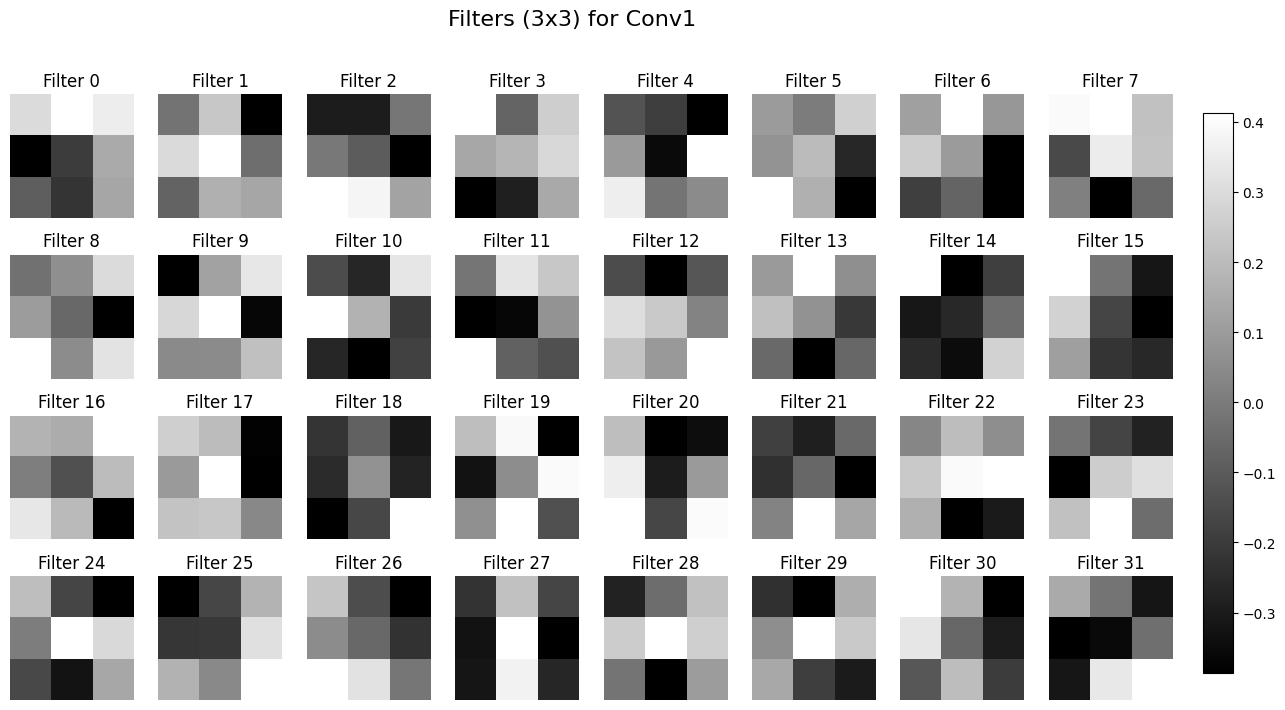

In [11]:
def plot_filters(conv_layer):
  filters = conv_layer.weight.data.cpu()

  fig, axes = plt.subplots(4, 8, figsize=(15, 8))

  fig.suptitle("Filters (3x3) for Conv1", fontsize=16)
  for i in range(32):
    ax = axes[i // 8, i % 8]
    f = filters[i].squeeze().numpy()
    im = ax.imshow(f, cmap='gray', interpolation='none')
    ax.set_title(f'Filter {i}')
    ax.axis('off')

  fig.subplots_adjust(right=0.9)
  cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
  fig.colorbar(im, cax=cbar_ax)

  plt.show()

plot_filters(grayscaleCNN.conv1)

**Analytical Question 1.2: Extract the weights of the filters from your first convolutional
layer. Plot them as images. Can you visually identify any rudimentary edge or texture
detection occurring? Briefly explain what these filters seem to be capturing.**

- If we look at filter 20s / 27 they are clearly **vertical edge/line detectors**. Filter 20 detects change from high to low to perform boundary detection, where as filter 27 clearly represents with strong black column on left and black column on right and will look for two changes in intensities low to high to low.

- Similary filter 11 acts as horizontal edge detector.

- Filter 2 as diagonal edge detector with clear high contract blocks.





## ** Task 2) Colored-MNIST (C-MNIST)
Standard MNIST relies on shape. In the real world, models often cheat by relying on background
colors or lighting rather than the actual object. We will simulate this using Colored-MNIST
dataset provided on LMS.


In [13]:
# MNIST Color
train_cminst_data, train_cminst_labels = torch.load(f'{DATASET_PATH}/train_biased.pt')
train_cminst_bdata, train_cminst_blabels = torch.load(f'{DATASET_PATH}/test_biased.pt')
train_cminst_ubdata, train_cminst_ublabels = torch.load(f'{DATASET_PATH}/test_unbiased.pt')

train_cminst_ds = torch.utils.data.TensorDataset(train_cminst_data, train_cminst_labels)
test_cminst_bds = torch.utils.data.TensorDataset(train_cminst_bdata, train_cminst_blabels)
test_cminst_ubds = torch.utils.data.TensorDataset(train_cminst_ubdata, train_cminst_ublabels)

all_cminst_labels = train_cminst_labels
classes_cminst = all_cminst_labels.unique()
print(all_cminst_labels)         # Output: tensor([5, 0, 4, ..., 5, 6, 8])
print(all_cminst_labels.unique()) # Output: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

total_train_cminst_len = len(train_cminst_ds)
train_cminst_size = int(total_train_cminst_len * 0.8)
val_cminst_size = total_train_cminst_len - train_cminst_size
train_cminst_subset, val_cminst_subset = torch.utils.data.random_split(train_cminst_ds, [train_cminst_size, val_cminst_size])

BATCH_SIZE = 64
train_cminst_loader = DataLoader(train_cminst_subset, batch_size=BATCH_SIZE, shuffle=True)
val_cminst_loader = DataLoader(val_cminst_subset, batch_size=BATCH_SIZE, shuffle=False)
test_cminst_bloader = DataLoader(test_cminst_bds, batch_size=BATCH_SIZE, shuffle=False)
test_cminst_ubloader = DataLoader(test_cminst_ubds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Train Samples: {len(train_cminst_ds)}")
print(f"Train Samples: {len(train_cminst_subset)}")
print(f"Validation Samples: {len(val_cminst_subset)}")

print(f"DateLoader batch size: {BATCH_SIZE}")
print(f"Trainning batches: {len(train_cminst_loader)}")
print(f"Validation batches: {len(val_cminst_loader)}")
print(f"Test Biased batches: {len(test_cminst_bloader)}")
print(f"Test Unbiased batches: {len(test_cminst_ubloader)}")

# # Print split sizes

tensor([5, 0, 4,  ..., 5, 6, 8])
tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])
Total Train Samples: 60000
Train Samples: 48000
Validation Samples: 12000
DateLoader batch size: 64
Trainning batches: 750
Validation batches: 188
Test Biased batches: 157
Test Unbiased batches: 157


Colored MNIST - Training Dataset Sample


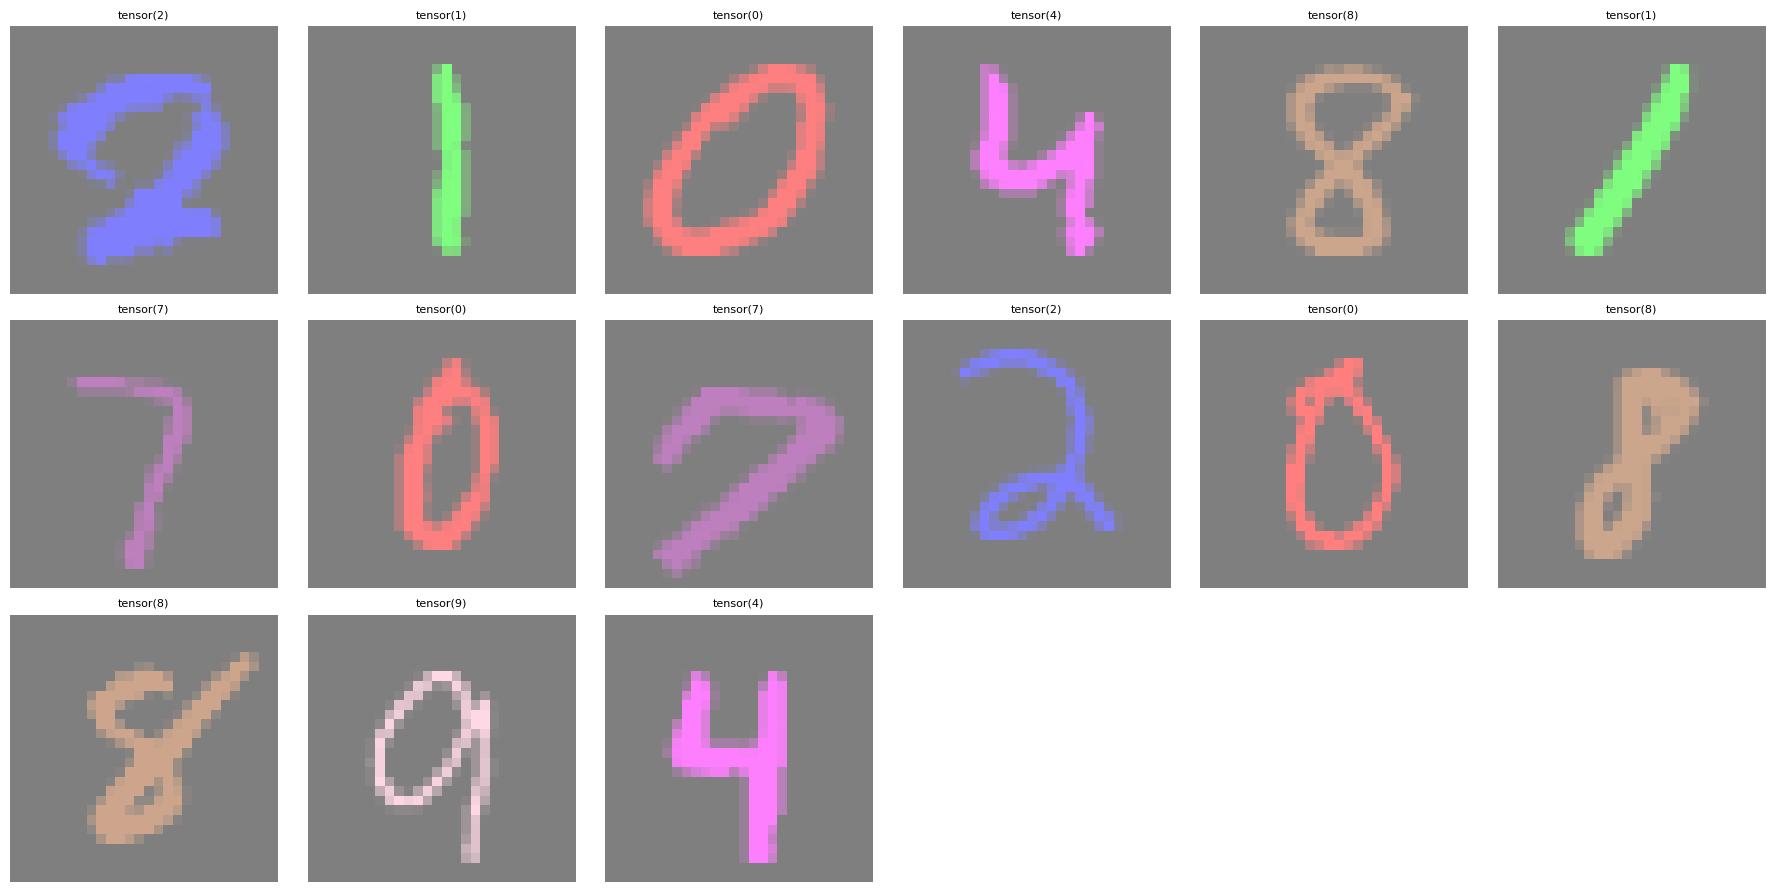

In [30]:
import math
def visualize_samples(dataloader, classes, num_samples=15):

    images, labels = next(iter(dataloader))

    images = images * 0.5 + 0.5

    cols = 6
    rows = math.ceil(num_samples/cols)
    plt.figure(figsize=(cols * 3, rows * 3))
    for i in range(num_samples):
      img_for_plot = images[i].permute(1, 2, 0)
      label_name = classes[labels[i].item()]

      plt.subplot(rows, cols, i  + 1)
      plt.imshow(img_for_plot)
      plt.title(label=label_name, fontsize=8)
      plt.axis('off')

    plt.tight_layout()
    plt.show()


print("Colored MNIST - Training Dataset Sample")
visualize_samples(train_cminst_loader, classes_cminst)



Colored MNIST - Biased Dataset Sample


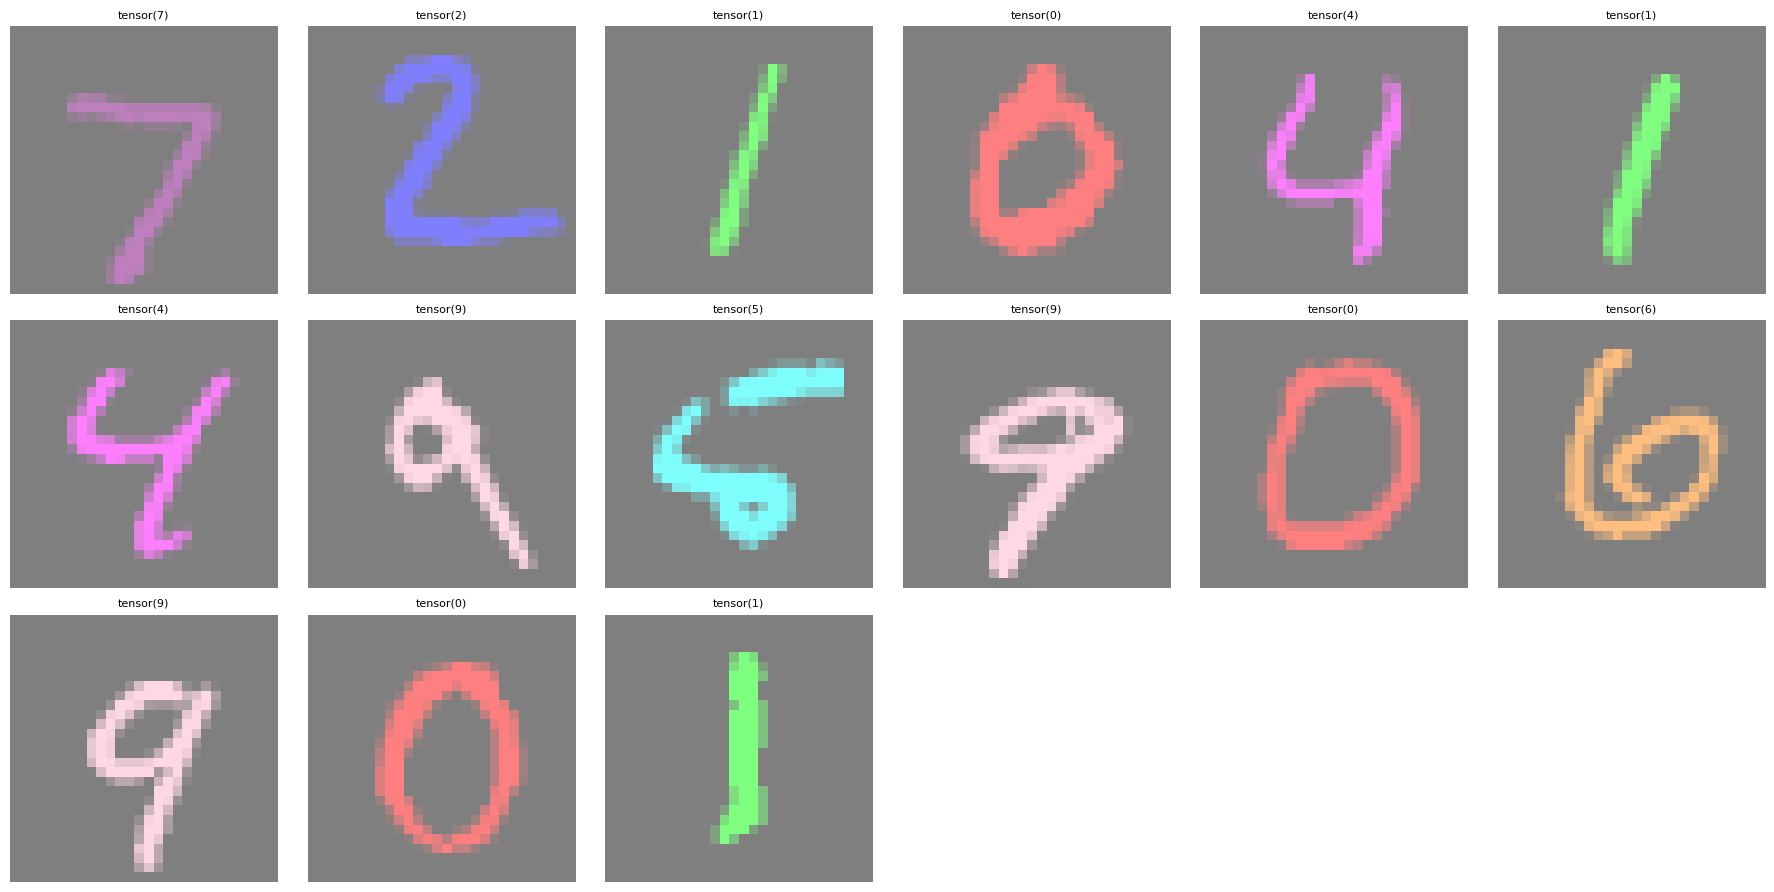

In [31]:
print("Colored MNIST - Biased Dataset Sample")

visualize_samples(test_cminst_bloader, classes_cminst)


Colored MNIST - UnBiased Dataset Sample


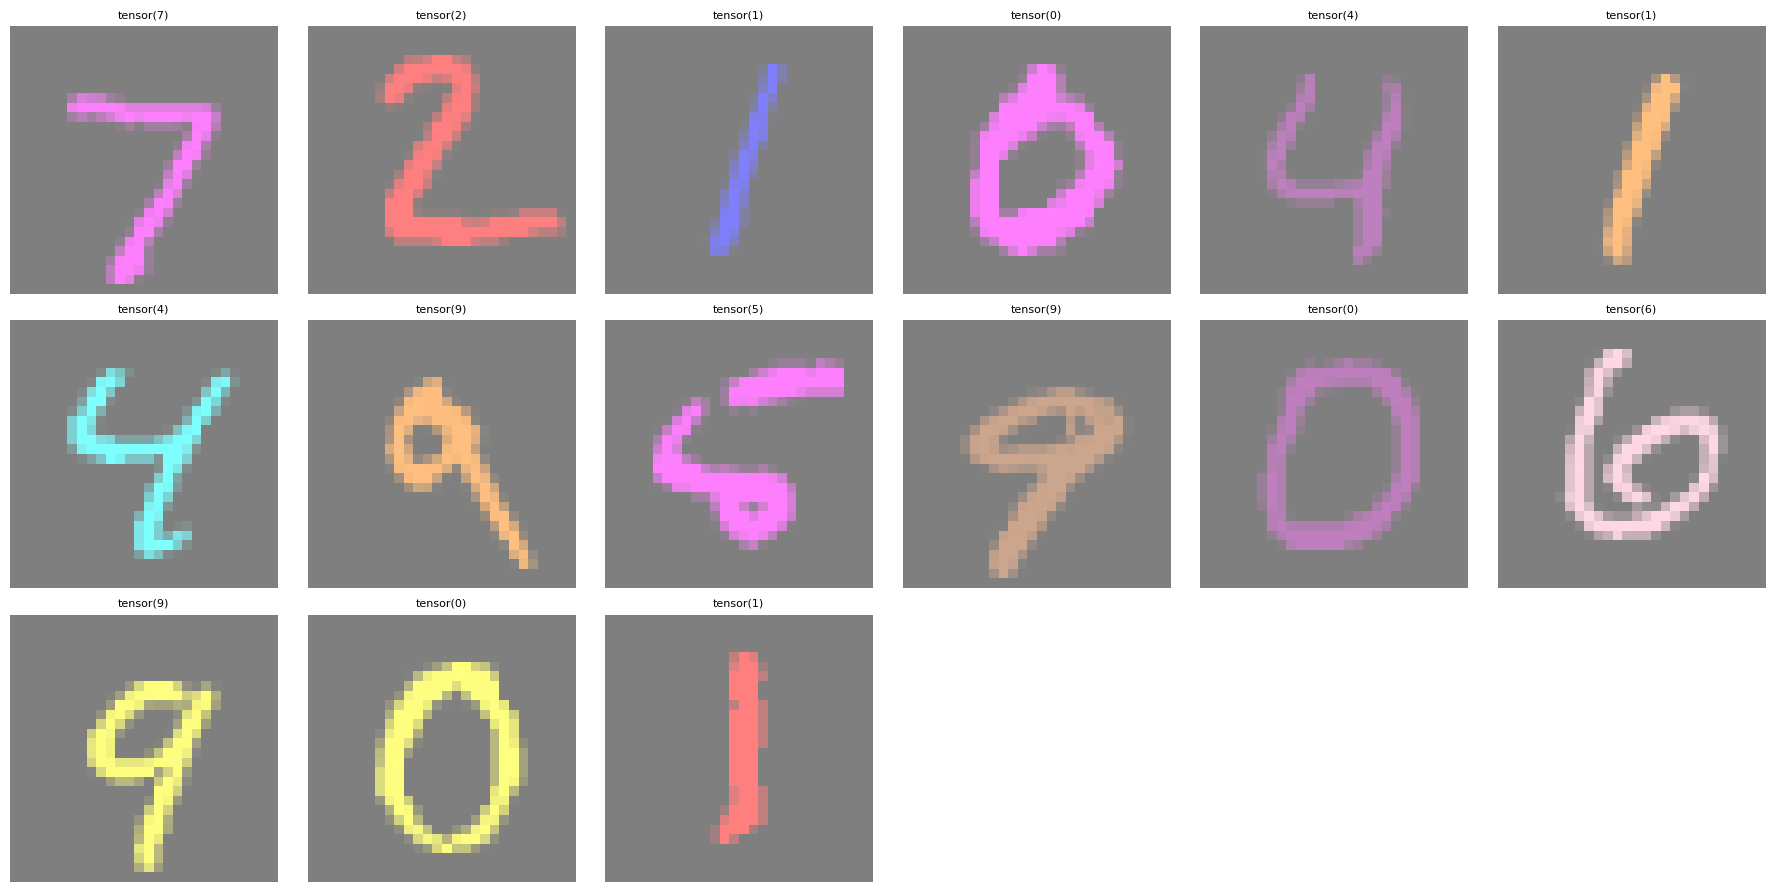

In [32]:
print("Colored MNIST - UnBiased Dataset Sample")

visualize_samples(test_cminst_ubloader, classes_cminst)

In [14]:
colorCNN = SimpleCNN(input_channels=3).to(DEVICE)
print(f"colorCNN Parameters: {count_parameters(colorCNN)}")

criterion_cel = nn.CrossEntropyLoss()
optimizer_adam = optim.Adam(colorCNN.parameters(), lr=0.001)
print("-" * 30)
print(" " * 30)
results = train_model(colorCNN,
                      train_cminst_loader,
                      val_cminst_loader,
                      criterion_cel,
                      optimizer_adam,
                      num_epochs=7)


colorCNN Parameters: 48266
------------------------------
                              
Epoch: 1/7 | Train Loss: 0.4086, Train Acc: 89.47% | Val Loss 0.15% Val Acc:96.17%
Epoch: 2/7 | Train Loss: 0.1195, Train Acc: 96.75% | Val Loss 0.10% Val Acc:97.27%
Epoch: 3/7 | Train Loss: 0.0694, Train Acc: 98.03% | Val Loss 0.05% Val Acc:98.55%
Epoch: 4/7 | Train Loss: 0.0510, Train Acc: 98.47% | Val Loss 0.04% Val Acc:98.83%
Epoch: 5/7 | Train Loss: 0.0404, Train Acc: 98.78% | Val Loss 0.05% Val Acc:98.55%
Epoch: 6/7 | Train Loss: 0.0332, Train Acc: 98.98% | Val Loss 0.03% Val Acc:98.97%
Epoch: 7/7 | Train Loss: 0.0312, Train Acc: 99.04% | Val Loss 0.03% Val Acc:99.10%


------------------------------
FINAL TEST RESULT
Test Loss: 0.0272
Test Accuracy: 99.19%
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99       980
           1       1.00      0.99      1.00      1135
           2       0.98      0.99      0.99      1032
           3       1.00      0.99      0.99      1010
           4       0.99      1.00      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      1.00      0.99       958
           7       0.99      0.99      0.99      1028
           8       0.98      0.99      0.99       974
           9       0.99      0.99      0.99      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

------------------------------
                              
------------------------------
---

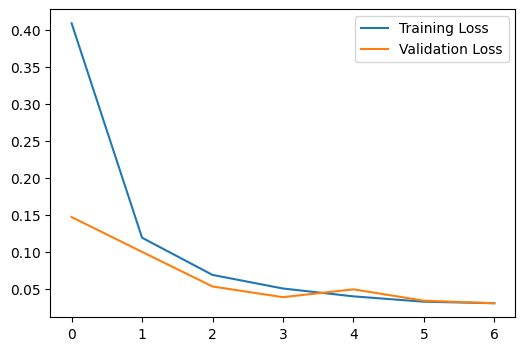

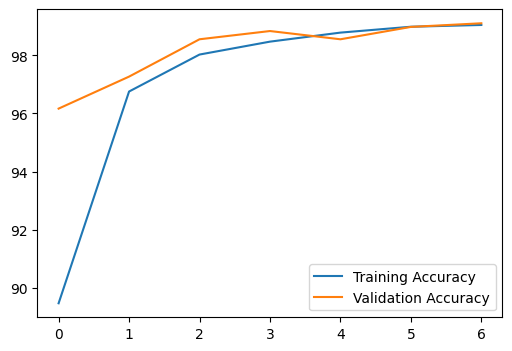

In [15]:

test_and_report(colorCNN, test_cminst_bloader, criterion_cel, classes_cminst)

print("-" * 30)
print(" " * 30)
plot_loss_acc(results)

In [22]:
test_and_report(colorCNN, test_cminst_ubloader, criterion_cel, classes_cminst)

print("-" * 30)
print(" " * 30)

------------------------------
FINAL TEST RESULT
Test Loss: 0.3508
Test Accuracy: 88.91%
------------------------------

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.81      0.87       980
           1       0.98      0.92      0.95      1135
           2       0.83      0.88      0.86      1032
           3       0.93      0.90      0.92      1010
           4       0.88      0.93      0.91       982
           5       0.91      0.89      0.90       892
           6       0.94      0.92      0.93       958
           7       0.91      0.90      0.91      1028
           8       0.75      0.90      0.82       974
           9       0.84      0.84      0.84      1009

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

------------------------------
                              


**3. Analytical Question 1.3: Report the accuracies for both test sets. You should observe a significant drop in performance on the unbiased test set. Explain this phenomenon mathematically and conceptually. Why did the optimizer prefer the color feature over the shape feature during training?**

Accuracy Bisased Test Dataset: 99.10%
Accuracy Un Bisased Test Dataset: 88.91%

There is a clear and significant drop (~10%) in performance of model on unbiased test data. The model almost perfectly classify on the biased dataset becasue of the color hint available in training and biased dataset, however in unbiased set the color no longer predict the digits accurately, forcing model to rely on shapes it missed to learn during the training phase.

Model give more importance to simple and strong prediction (gradient magnitude) which in our case is the color, becasue color is strongly correlated with the digits making it a simple and low cost shortcut compared to learning complex digit shapes.

Mathematically, as we know that model learns by finding a set of weights that results in minimum loss during the back propogation.

$$\hat{\vec{w}} = \arg \min_{\vec{w}} L$$

We find these weights via gradient descent (GD), where iteratively update weigths which results in minimum loss:

$$W_{t+1} = W_t - \alpha \frac{\partial L}{\partial W_t}$$

$\frac{\partial L}{\partial W_t}$: represent Loss gradient w.r.t to current weight at t.

As the color feature is highly correlated with the digit label, thus the gradient of Loss w.r.t color sensitive weights will produce much larger gradients then shape sensitive weights.

$$\left| \frac{\partial L}{\partial W_{color}} \right| \gg \left| \frac{\partial L}{\partial W_{shape}} \right|$$

As the weight update step is proportional for the gradient, the models weight thus inclinde more towards a solution that relies on color, ignoring the shape features.


**4. Analytical Question 1.4: Propose training strategies that could force the network to ignore the color and focus on the shape of the digits (You are not required to provide code for this).**

As we have seen the model is giving preference to the color feature therefore to force network to ignore the color and give more importance to shape we can introduce the following:

- **Data Augmenation**: By adding color randomization we can break this strong correlation between color and label, forcing model to learn other features like shape.

- **Grayscale Preprocessing**: Remove color entirely and force model to learn spatial features like edges and shapes, instead of focusing on color.



# **Task 2 - Transfer Learning**

Objective: Utilize a pre-trained model on a more complex dataset (STL-10) and use GradCAM
(Gradient-weighted Class Activation Mapping) to visually interpret the model’s decision-making
process.


**Part A: Fine-tuning ResNet-18**


In [6]:


mean = [0.485, 0.456, 0.406]
std = [0.229, 0.224, 0.225]
resnet_transformer_train = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean , std)
])

resnet_transformer_test = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(mean , std)
])

stl_path = os.path.join(root_path, 'stl10_binary')


train_stl10_ds = datasets.STL10(root=stl_path, transform=resnet_transformer_train, download=True, split='train')
test_stl10_ds = datasets.STL10(root=stl_path, transform=resnet_transformer_test, download=True, split='test')

# Get the first sample
image, label = train_stl10_ds[0]

# If you haven't applied transforms, 'image' is a PIL Image object
# If you used transforms.ToTensor(), it's a Torch Tensor
print(f"Image Type: {type(image)}")
print(f"Image Shape/Size: {image.size if hasattr(image, 'size') else image.shape}")
print(f"Label index: {label}")

total_train_len = len(train_stl10_ds)
train_stl10_size = int(total_train_len * 0.8)
val_stl10_size = total_train_len - train_stl10_size
train_stl10_subset, val_stl10_subset = torch.utils.data.random_split(train_stl10_ds, [train_stl10_size, val_stl10_size])


all_stl10_labels = train_stl10_ds.classes
print(all_stl10_labels)

BATCH_SIZE = 64
train_stl10_loader = DataLoader(train_stl10_subset, batch_size=BATCH_SIZE, shuffle=True)
val_stl10_loader = DataLoader(val_stl10_subset, batch_size=BATCH_SIZE, shuffle=False)
test_stl10_loader = DataLoader(test_stl10_ds, batch_size=BATCH_SIZE, shuffle=False)

print(f"Total Train Samples: {len(train_stl10_ds)}")
print(f"Train Samples: {len(train_stl10_subset)}")
print(f"Validation Samples: {len(val_stl10_subset)}")

print(f"DateLoader batch size: {BATCH_SIZE}")
print(f"Trainning batches: {len(train_stl10_loader)}")
print(f"Validation batches: {len(val_stl10_loader)}")
print(f"Test batches: {len(test_stl10_loader)}")


Image Type: <class 'torch.Tensor'>
Image Shape/Size: <built-in method size of Tensor object at 0x7a930d3b67b0>
Label index: 1
['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']
Total Train Samples: 5000
Train Samples: 4000
Validation Samples: 1000
DateLoader batch size: 64
Trainning batches: 63
Validation batches: 16
Test batches: 125


In [7]:
print(image.shape)

torch.Size([3, 224, 224])


## **2) Model A — CNN From Scratch**

**Task: Define your own small CNN architecture for training from scratch.**

In [11]:
from torchvision import models
from torchsummary import summary
resnet_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

for params in resnet_model.parameters():
  params.requires_grad = False

num_features = resnet_model.fc.in_features

# print(num_features)
resnet_model.fc = nn.Linear(num_features, 10)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet_model.to(device)

# summary(resnet_model, (3, 224, 224))



In [19]:
optimzer_stl10 = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.001)
criterion_stl10 = nn.CrossEntropyLoss()

print("-" * 30)
print(" " * 30)
results = train_model(resnet_model,
                      train_stl10_loader,
                      val_stl10_loader,
                      criterion_stl10,
                      optimzer_stl10,
                      num_epochs=7)


------------------------------
                              
Epoch: 1/7 | Train Loss: 0.3346, Train Acc: 92.53% | Val Loss 0.24% Val Acc:93.40%
Epoch: 2/7 | Train Loss: 0.2336, Train Acc: 93.85% | Val Loss 0.20% Val Acc:93.60%
Epoch: 3/7 | Train Loss: 0.1950, Train Acc: 94.72% | Val Loss 0.18% Val Acc:93.90%
Epoch: 4/7 | Train Loss: 0.1776, Train Acc: 94.78% | Val Loss 0.16% Val Acc:94.90%
Epoch: 5/7 | Train Loss: 0.1511, Train Acc: 95.50% | Val Loss 0.18% Val Acc:93.40%
Epoch: 6/7 | Train Loss: 0.1470, Train Acc: 95.65% | Val Loss 0.15% Val Acc:94.60%
Epoch: 7/7 | Train Loss: 0.1322, Train Acc: 96.17% | Val Loss 0.16% Val Acc:94.20%


------------------------------
FINAL TEST RESULT
Test Loss: 0.1057
Test Accuracy: 97.12%
------------------------------

Classification Report:
               precision    recall  f1-score   support

    airplane       0.99      0.99      0.99       401
        bird       0.98      0.98      0.98       400
         car       0.99      0.98      0.98       409
         cat       0.99      0.93      0.96       406
        deer       0.92      0.97      0.95       399
         dog       0.91      0.97      0.94       390
       horse       0.98      0.92      0.95       404
      monkey       0.98      0.99      0.98       390
        ship       0.99      0.98      0.99       406
       truck       0.98      0.97      0.98       395

    accuracy                           0.97      4000
   macro avg       0.97      0.97      0.97      4000
weighted avg       0.97      0.97      0.97      4000

------------------------------
                              
------------------------------
---

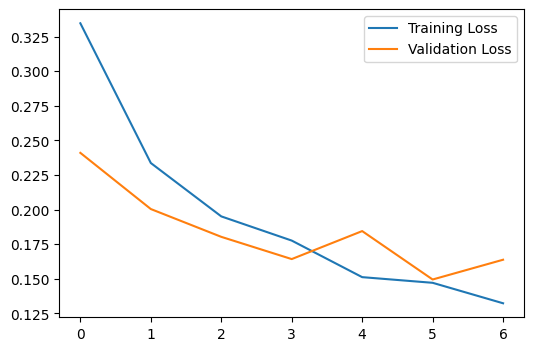

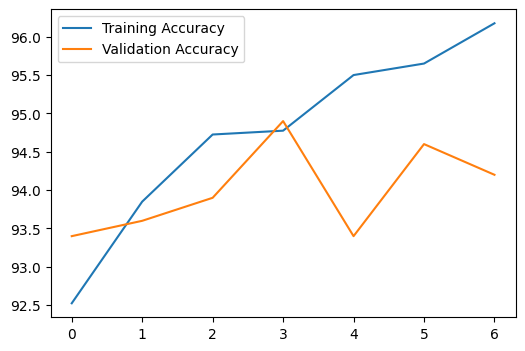

In [20]:
test_loss, test_val, y_true, y_pred = test_and_report(resnet_model, train_stl10_loader, criterion_stl10, all_stl10_labels)

print("-" * 30)
print(" " * 30)
plot_loss_acc(results)

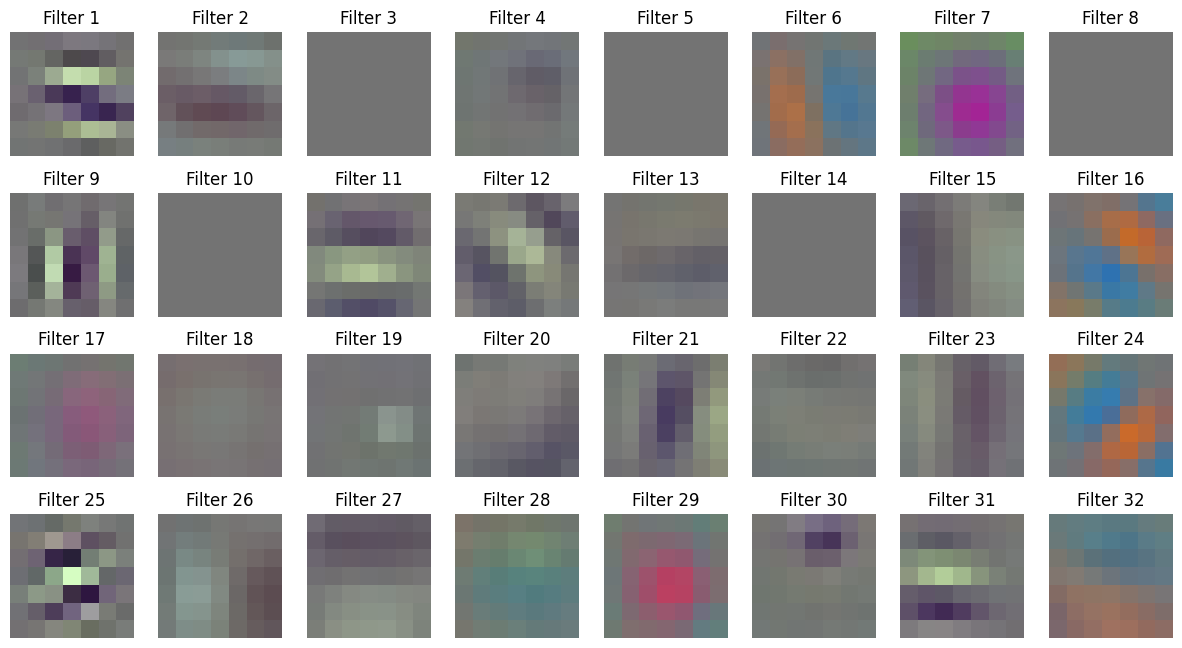

In [21]:
kernels = resnet_model.conv1.weight.detach().cpu()

kernels = kernels - kernels.min()
kernels = kernels / kernels.max()

fig, axes = plt.subplots(4, 8, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
  ax.imshow(kernels[i].permute(1, 2, 0))
  ax.set_title(f'Filter {i+1}')
  ax.axis('off')

plt.show()

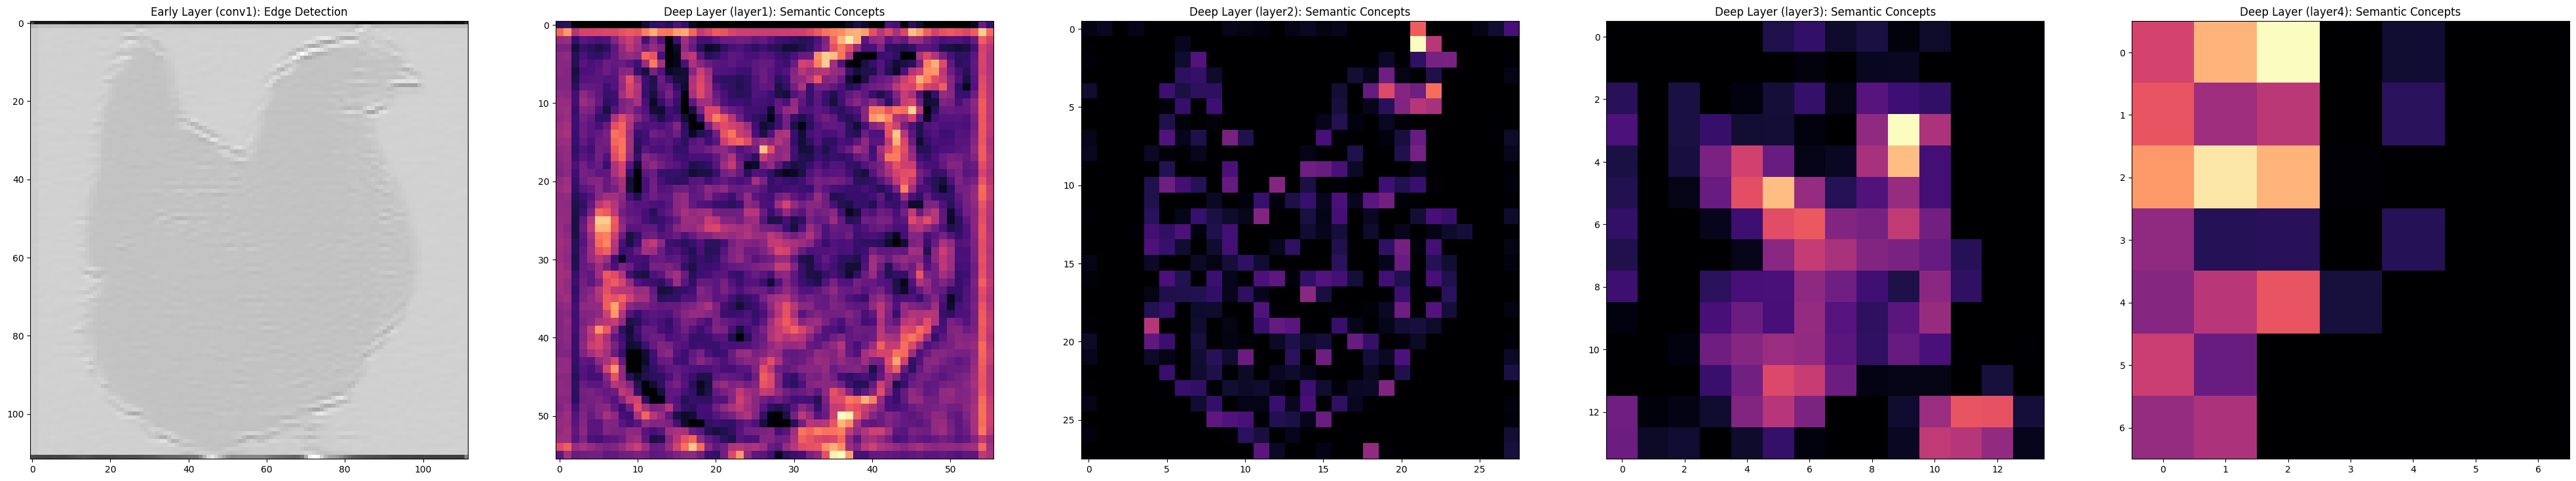

In [22]:
import torch
import matplotlib.pyplot as plt

# 1. Get a sample image from your loader
data_iter = iter(train_stl10_loader)
images, labels = next(data_iter)
img = images[0].unsqueeze(0).to(device) # Pick the first image

# 2. Extract features from an early and a late layer
# We use the model's sub-modules directly
with torch.no_grad():
    early_features = resnet_model.conv1(img)
    # To get deep features, we go through the blocks
    x = resnet_model.maxpool(resnet_model.relu(resnet_model.bn1(early_features)))
    x = resnet_model.layer1(x)
    deep_features_1 = x
    x = resnet_model.layer2(x)
    deep_features_2 = x
    x = resnet_model.layer3(x)
    deep_features_3 = x
    deep_features_4 = resnet_model.layer4(x)

# 3. Plot them
fig, ax = plt.subplots(1, 5, figsize=(50, 10))

# Plot one channel from early features (detecting edges)
ax[0].imshow(early_features[0, 0].cpu(), cmap='gray')
ax[0].set_title("Early Layer (conv1): Edge Detection")

# Plot one channel from deep features (detecting object parts)
ax[1].imshow(deep_features_1[0, 0].cpu(), cmap='magma')
ax[1].set_title("Deep Layer (layer1): Semantic Concepts")

# Plot one channel from deep features (detecting object parts)
ax[2].imshow(deep_features_2[0, 0].cpu(), cmap='magma')
ax[2].set_title("Deep Layer (layer2): Semantic Concepts")


# Plot one channel from deep features (detecting object parts)
ax[3].imshow(deep_features_3[0, 0].cpu(), cmap='magma')
ax[3].set_title("Deep Layer (layer3): Semantic Concepts")

# Plot one channel from deep features (detecting object parts)
ax[4].imshow(deep_features_4[0, 0].cpu(), cmap='magma')
ax[4].set_title("Deep Layer (layer4): Semantic Concepts")


plt.show()

**Question
Why is it computationally and functionally beneficial to
freeze the early layers of a pre-trained network when fine-tuning on a relatively small
dataset like STL-10? What type of features are stored in those early layers compared to
the later layers?**

**Reduced Compute and Memory needs**
When the early layers of a pre-trained network are frozen, we don't just skip updating weights; we also skip the gradients calculation during the back prop as we donot want to update the weight for those layers. It means that we are able to avoid weight updates a large number of parameters. This significantly reduces the comupational and memory requirement during the training, allowing for larger batch sizes on the same hardware.

**Use a large model for a smaller dataset**

An pre-trainned model (trained on a very large divers dataset) has leared general features of that dataset. By freezing the early layers and then training only the later ones on a small dataset the model adapts to the task specfic patterns while retaining the original general knowledge it had through the frozen weights, allowing model to generalize better event when the dataset is small.

However if we retrain all the layers a large model like ResNet18 on a small dataset it will simiply memories the training set becasue the model is too complex for such a small dataset and will thus lead to overfit and poor test accuracy

**Feature Comparison Early Layers Vs Later Layers:**

Early Layers learn about the Low-level generic features like edges or color gradients etc. These feature are generic and are not specfic to a given domain, e.g. an edge is an edge either in a medical scan or in a photo of a dog.

However the later Layers learn about various High-level features which may have sementics of that specfic domain for example complex shapes, object parts, and textures etc. These are the features of a domain specific and they combine the already learned primitive feature like edges from early layers into recognizable concepts like eyes, wheels, or wings.

In [23]:
pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 50.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=dcd314ab7a26b753708928fad299d67d1f0762160c9f53d50ed6190f77d538c6
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


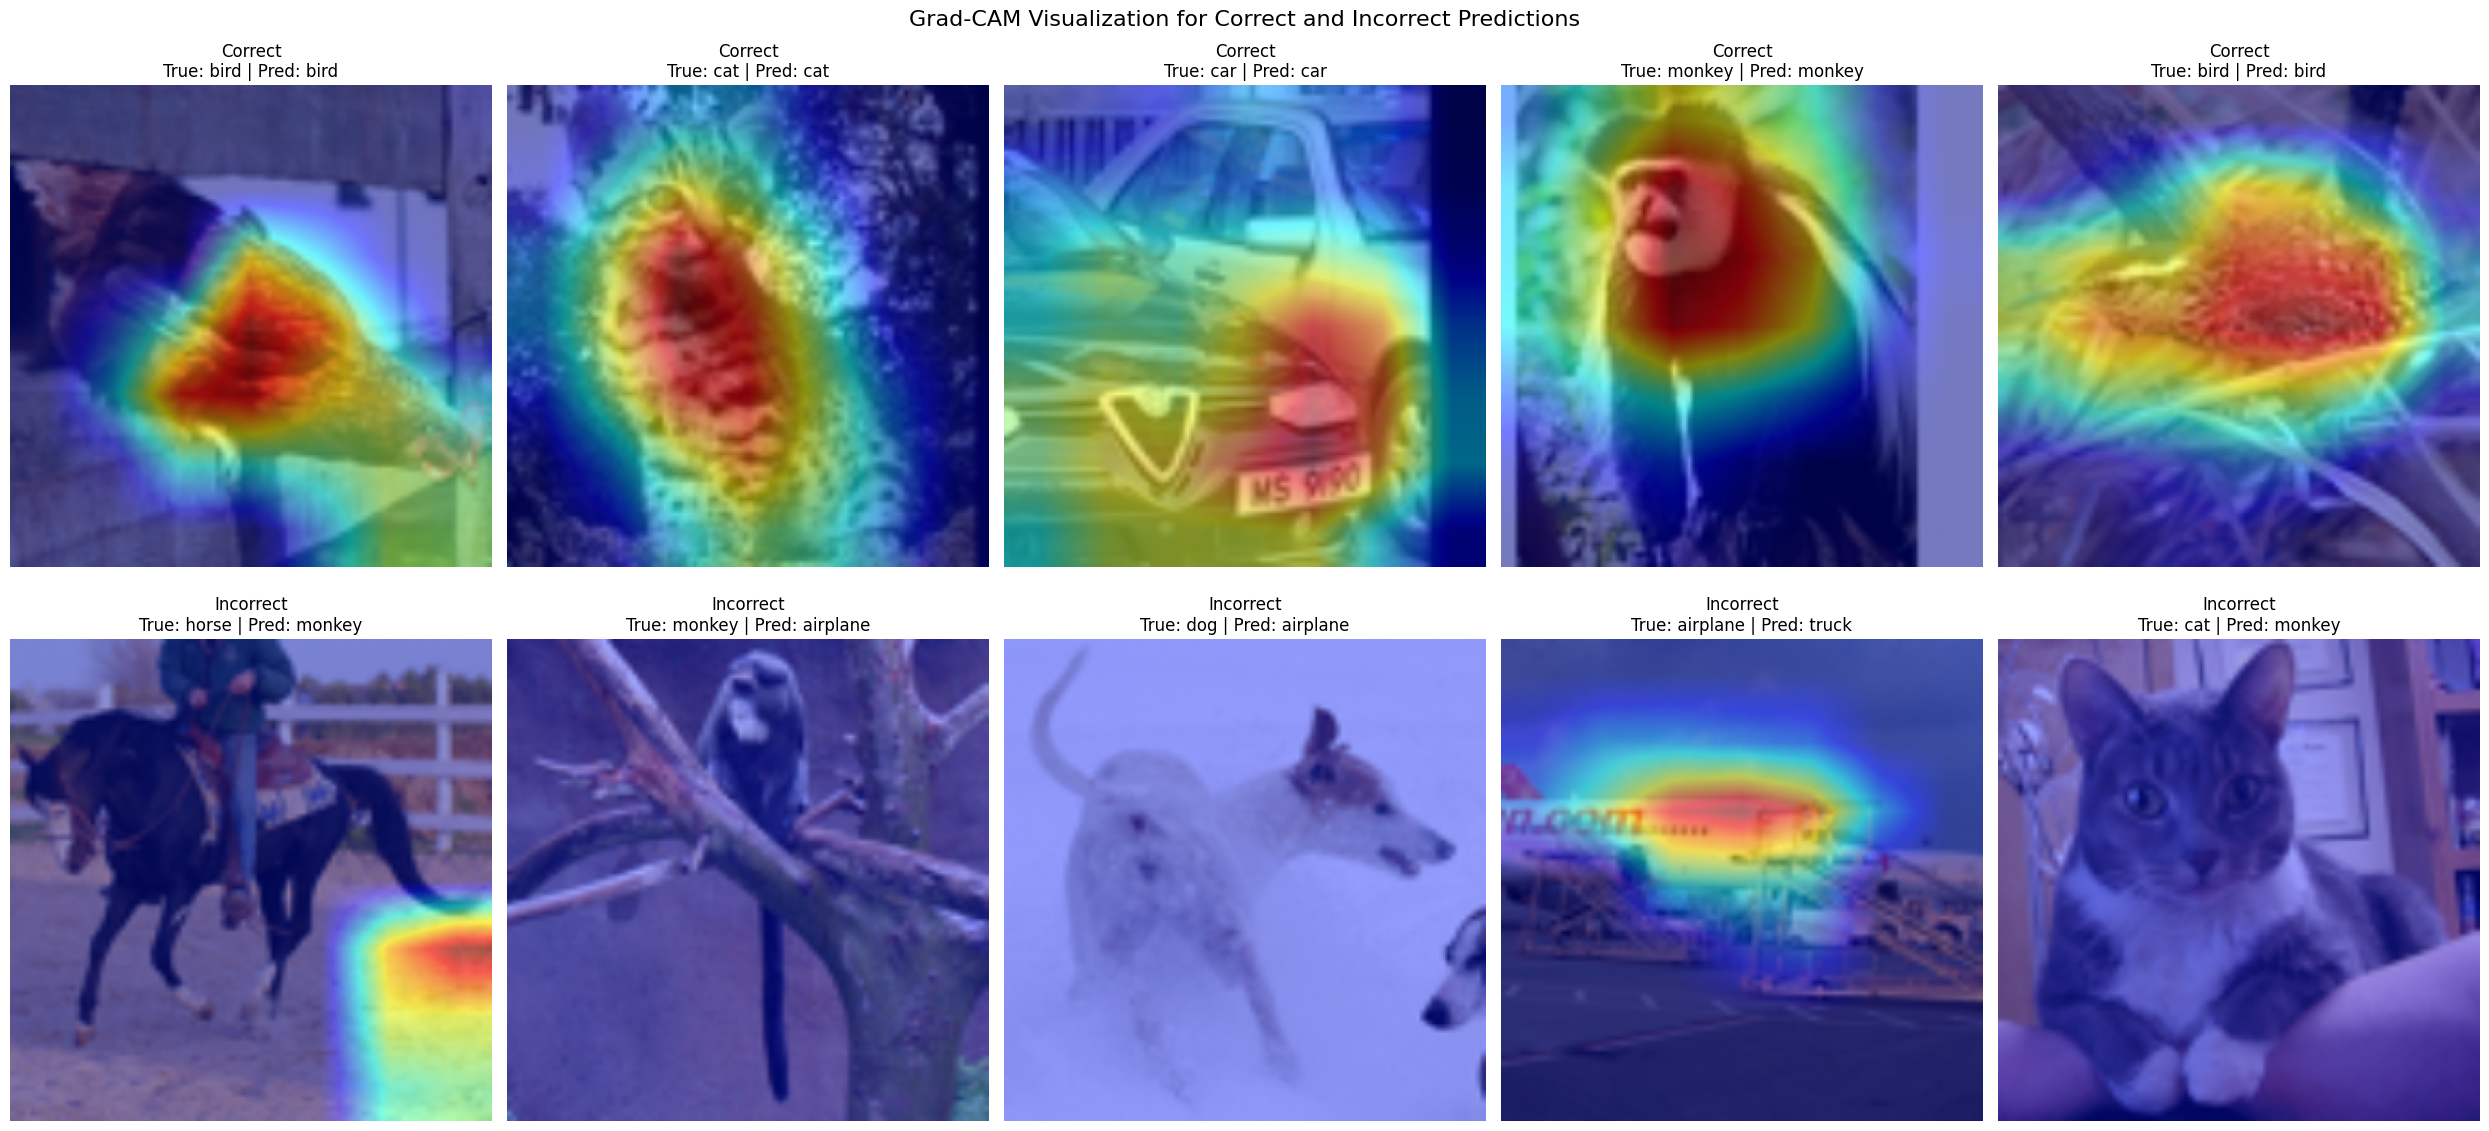

In [39]:


from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image, preprocess_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget


correct_predictions = []
incorrect_predictions = []
for i in range(len(y_pred)):

  if len(correct_predictions) ==5 and len(incorrect_predictions) ==5:
    break

  img_tensor, true_label = test_stl10_ds[i]
  pred_label = y_pred[i]

  if true_label == pred_label and  len(correct_predictions) < 5:
      correct_predictions.append({
          "image" : img_tensor,
          "label" : true_label,
          "predicted": pred_label,
          "index":i})
      # print(f"i: {i}")

  elif true_label != pred_label and  len(incorrect_predictions) < 5:
    incorrect_predictions.append({
          "image" : img_tensor,
          "label" : true_label,
          "predicted": pred_label,
          "index": i})

for module in resnet_model.modules():
  if isinstance(module, torch.nn.ReLU):
    module.inplace = False

for param in resnet_model.parameters():
  param.requires_grad = True

resnet_model.eval()

target_layers = [resnet_model.layer4]
cam = GradCAM(model=resnet_model, target_layers=target_layers)

sample_predictions = correct_predictions + incorrect_predictions

fig, ax = plt.subplots(2, 5, figsize=(25, 12))
ax = ax.flatten()
titles = ["Correct Predictions", "Incorrect Predictions"]

for i, ex in enumerate (sample_predictions):
  # print(i)
  input_tensor = ex["image"].unsqueeze(0).to(device)
  targets = [ClassifierOutputTarget(ex["predicted"])]
  grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

  rgb_img = ex["image"].permute(1, 2, 0).cpu().numpy()
  rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

  visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

  category = "Correct" if i < 5 else "Incorrect"
  true_label = all_stl10_labels[ex["label"]]
  predicted_label = all_stl10_labels[ex["predicted"]]

  ax[i].imshow(visualization)
  ax[i].set_title(f"{category}\nTrue: {true_label} | Pred: {predicted_label}")
  ax[i].axis('off')

plt.suptitle("Grad-CAM Visualization for Correct and Incorrect Predictions", fontsize=16)
plt.tight_layout()

plt.show()


**Analytical Question 2.2:**

**Answer:** Looking at the first row plots in above cells output we can present a very positive conslusion:

- In 4 out of 4 correct classifications ( bird, cat, and monkey) the heatmaps are appropriately centered on the centeral part and the head of the underlying animal. It means that the model is using more disciminative features like cats fur or monkey's face.

- In the 3 image model was also able to correctly classify a car where the heatmap(red/yellow) is focused strongly around the number plate and headlight of the car. Model is able to used these localized feature / shapes to make correct classification.

Therefore we can say that model is largely focusing on the primary shapes / objects, and when model relyed these feature its been able to make correct predictions, instead of relying on the background like sky or grass.





**Analytical Question 2.3:**

**Answer:** However, when we review the 5 incorrect predictions, we see a clear pattern that for some images background distractions caught model attention more than the any feature of the main object or model failed to distinguish between structure wise similar objects, or there is actaully no heatmap observed showing that the gradients were very weak for these activataions.

- Horse vs Monkey: the model is focusing on the background, probably a fence or just grass and missed the horse entirely.

- In multiple images (2nd and 5th) there is no heat maps which show model is not able locate any strong features and just picked the class with a probabity slightly higher than others.

- In image 4 it failed to distinguish between similar features (long metallic cyliner) of airplane vs truck

We can say that the  failures are basically due to the background distraction or some structural similarities.